In [82]:
import networkx as nx
import matplotlib.pyplot as plt
from concept_creator.neo4j_to_networkx import Neo4jToNetworkx
import json
import dotenv
from neo4j import GraphDatabase, Session
from typing import List
import os

dotenv.load_dotenv()

True

In [83]:

def visualize_networkx_graph(graph: nx.Graph) -> None:
    # Create a new figure
    plt.figure(figsize=(12, 8))

    node_to_color = {
        "IntersectionPoint": "red",
        "CornerPoint": "green",
        "EndPoint": "blue",
        "QuadrantChangePoint": "purple",
        "StartPoint": "orange"
    }

    # Get node colors based on node labels
    node_colors = []
    labels_for_nodes = {}

    for node in graph.nodes():
        # Get labels from node attributes - try different ways to access labels
        node_data = graph.nodes[node]
        
        # First, try to get labels as a direct attribute
        labels = node_data.get('labels', [])
        
        # If labels is empty, try to get them from node_labels attribute
        if not labels and 'node_labels' in node_data:
            labels = node_data['node_labels']
        
        # If still empty, check if any attribute has 'label' in its name
        if not labels:
            for key in node_data:
                if 'label' in key.lower() and node_data[key]:
                    if isinstance(node_data[key], list):
                        labels = node_data[key]
                    else:
                        labels = [str(node_data[key])]
                    break
        
        # If everything fails, use a default label
        if not labels:
            labels = ["Point"]
        
        # Store labels for node labeling
        labels_for_nodes[node] = ', '.join(str(label) for label in labels) if labels else str(node)
        labels_for_nodes[node] = labels_for_nodes[node] + f"\n{node.split(':')[-1]}"
        
        # Check if any label matches our color mapping
        color = 'lightblue'  # Default color
        for label in labels:
            label_str = str(label)  # Convert to string if it's not already
            if label_str in node_to_color:
                color = node_to_color[label_str]
                break
        
        node_colors.append(color)

    # Draw the graph with explicit node_color parameter
    pos = nx.spring_layout(graph)  # Calculate positions
    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=1500)
    nx.draw_networkx_edges(graph, pos)
    nx.draw_networkx_labels(graph, pos, labels=labels_for_nodes, font_size=8)
    plt.axis('off')
    plt.show()

In [84]:
properties_to_ignore = ["image_id", "concept_id", "elementId", "id", "uuid", "session_id"]
def print_table_of_properties(graph: nx.Graph) -> None:
    """Print a table of properties for each node in the graph."""
    print(f"Node\tProperties")
    for node in graph.nodes():
        properties = graph.nodes[node].copy()
        filtered_properties = {k: v for k, v in properties.items() if k not in properties_to_ignore}
        print(f"{node}\t{filtered_properties}")

In [85]:
def extract_concepts_ids_of_interest(session: Session, concept_of_interest: str) -> List[str]:
    """Extract graph from Neo4j and convert to NetworkX format."""
    query = """
    MATCH (n)
    WHERE n.concept_id STARTS WITH $concept_of_interest
    RETURN DISTINCT n.concept_id as concept_id
    """
    result = session.run(query, concept_of_interest=concept_of_interest)
    concepts_ids_of_interest = [record['concept_id'] for record in result]
    return concepts_ids_of_interest

In [86]:
# Read file
with open('latest_results.json', 'r') as file:
    results = json.load(file)
    
image_id = results['image_id']
concept_of_interest = results['parameters']['concept_of_interest']
concept_graphs_of_interest = {}
activated_concepts_with_scores = [(x['concept_id'], x['combined_score']) for x in results['classification_results']]

concept_graphs = {}

driver = GraphDatabase.driver(os.getenv('NEO4J_DSN'), auth=(os.getenv('NEO4J_USER'), os.getenv('NEO4J_PASSWORD')))
with driver.session() as session:
    image_graph = Neo4jToNetworkx.extract_image_graph(session, image_id)
    for concept_id, combined_score in activated_concepts_with_scores:
        concept_graph = Neo4jToNetworkx.extract_concept_graph(session, concept_id)
        concept_graphs[concept_id] = concept_graph
    concepts_ids_of_interest = extract_concepts_ids_of_interest(session, "3")
    for concept_id in concepts_ids_of_interest:
        concept_graphs_of_interest[concept_id] = Neo4jToNetworkx.extract_concept_graph(session, concept_id)

Visualizing image graph


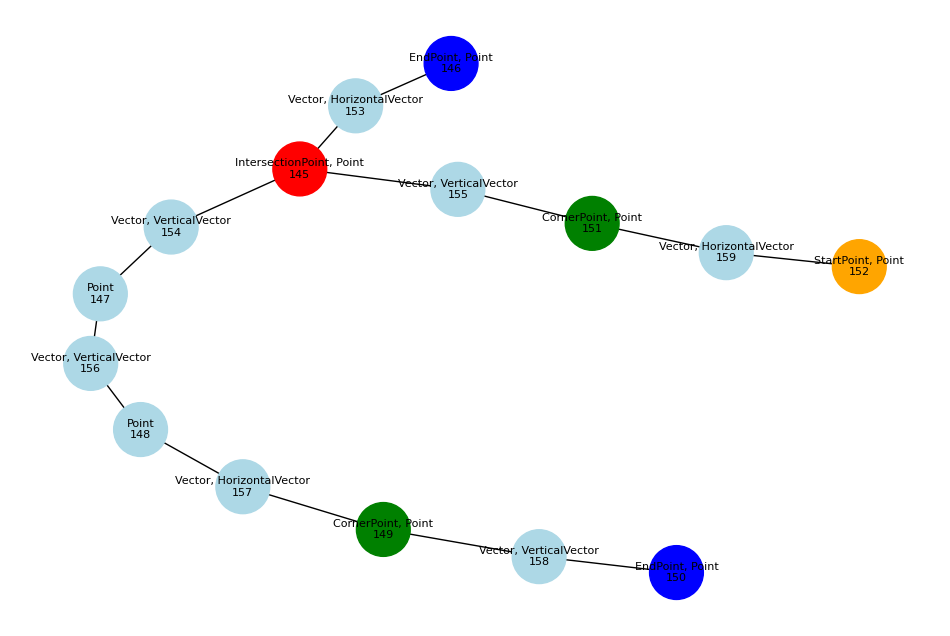

Node	Properties
4:302ef79a-0b04-4334-82b9-01f9754b0950:145	{'labels': {'IntersectionPoint', 'Point'}, 'endpoints_count': 2, 'segments': ['center_horizontal', 'right'], 'cycle_count': 0, 'is_quadrant_change': 1, 'vectors_count': 7, 'contour_type': 'OPEN', 'angle': 190, 'normalized_x': 0.3, 'relative_distance': 0.2, 'normalized_y': -0.2, 'monotony': 'NON_MONOTONIC', 'intersection_points_count': 1, 'corner_points_count': 2, 'quadrant_change_count': 4, 'y': 42.48074263010356, 'x': 62.71727861317785}
4:302ef79a-0b04-4334-82b9-01f9754b0950:146	{'labels': {'EndPoint', 'Point'}, 'endpoints_count': 2, 'segments': ['center_horizontal', 'center_vertical'], 'cycle_count': 0, 'vectors_count': 7, 'contour_type': 'OPEN', 'normalized_x': -0.0, 'relative_distance': 0.0, 'normalized_y': -0.0, 'monotony': 'NON_MONOTONIC', 'intersection_points_count': 1, 'corner_points_count': 2, 'quadrant_change_count': 4, 'y': 49.812696915303476, 'x': 48.82869783995545}
4:302ef79a-0b04-4334-82b9-01f9754b0950:147	{'label

In [87]:

print("Visualizing image graph")
visualize_networkx_graph(image_graph)
print_table_of_properties(image_graph)

Visualizing concept graphs of interest
Visualizing concept graph of interest 3_2


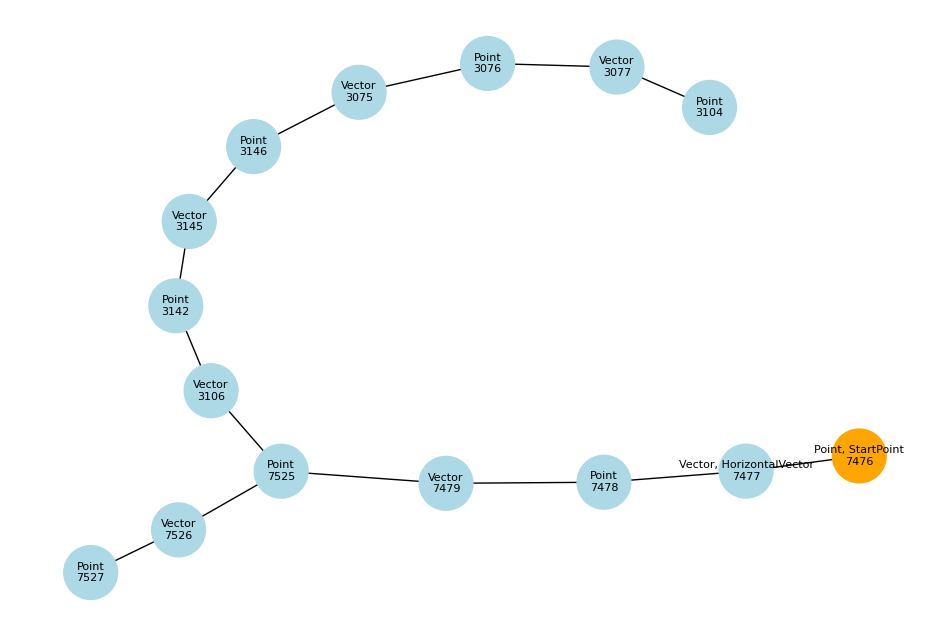

Node	Properties
4:302ef79a-0b04-4334-82b9-01f9754b0950:3075	{'labels': ['Vector'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:3076	{'labels': ['Point'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:3077	{'labels': ['Vector'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:3104	{'labels': ['Point'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:3106	{'labels': ['Vector'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:3142	{'labels': ['Point'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:3145	{'labels': ['Vector'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-

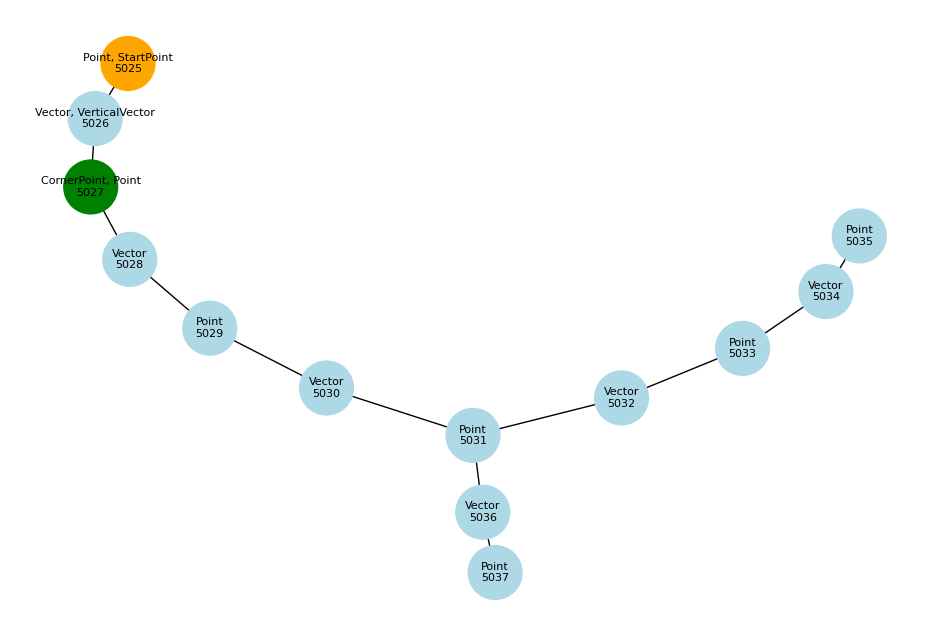

Node	Properties
4:302ef79a-0b04-4334-82b9-01f9754b0950:5025	{'labels': ['Point', 'StartPoint'], 'monotony': 'NON_MONOTONIC', 'segments': ['top', 'left'], 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:5026	{'labels': ['Vector', 'VerticalVector'], 'monotony': 'NON_MONOTONIC', 'relative_distance': 0.4, 'segments': ['top', 'left'], 'cycle_count': 0, 'half_plane': 'lower', 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:5027	{'labels': ['CornerPoint', 'Point'], 'monotony': 'NON_MONOTONIC', 'relative_distance': 0.5, 'segments': ['top', 'left'], 'cycle_count': 0, 'is_quadrant_change': 1, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:5028	{'labels': ['Vector'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:5029	{'labels': ['Point'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:5030	{'labels': ['Vector

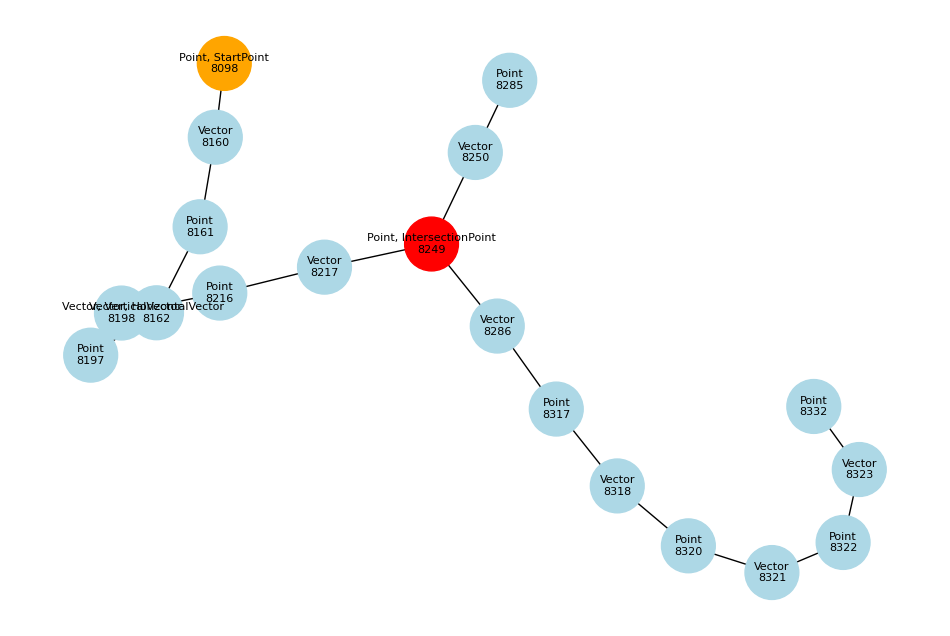

Node	Properties
4:302ef79a-0b04-4334-82b9-01f9754b0950:8098	{'labels': ['Point', 'StartPoint'], 'monotony': 'NON_MONOTONIC', 'endpoints_count': 2, 'relative_distance': 0.3, 'intersection_points_count': 1, 'cycle_count': 0, 'corner_points_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:8160	{'labels': ['Vector'], 'monotony': 'NON_MONOTONIC', 'endpoints_count': 2, 'relative_distance': 0.3, 'intersection_points_count': 1, 'cycle_count': 0, 'corner_points_count': 0, 'contour_type': 'OPEN', 'quadrant': 4}
4:302ef79a-0b04-4334-82b9-01f9754b0950:8161	{'labels': ['Point'], 'endpoints_count': 2, 'segments': ['top', 'center_vertical'], 'cycle_count': 0, 'contour_type': 'OPEN', 'relative_distance': 0.3, 'normalized_y': -0.4, 'monotony': 'NON_MONOTONIC', 'intersection_points_count': 1, 'corner_points_count': 0}
4:302ef79a-0b04-4334-82b9-01f9754b0950:8162	{'labels': ['Vector', 'HorizontalVector'], 'endpoints_count': 2, 'segments': ['top', 'center_vertical'], 'cycle_count':

In [88]:
print("Visualizing concept graphs of interest")
for concept_id, concept_graph in concept_graphs_of_interest.items():
    print(f"Visualizing concept graph of interest {concept_id}")
    visualize_networkx_graph(concept_graph)
    print_table_of_properties(concept_graph)

Visualizing concept graphs
Visualizing concept graph for 2_3 with score 0.9999999999999999


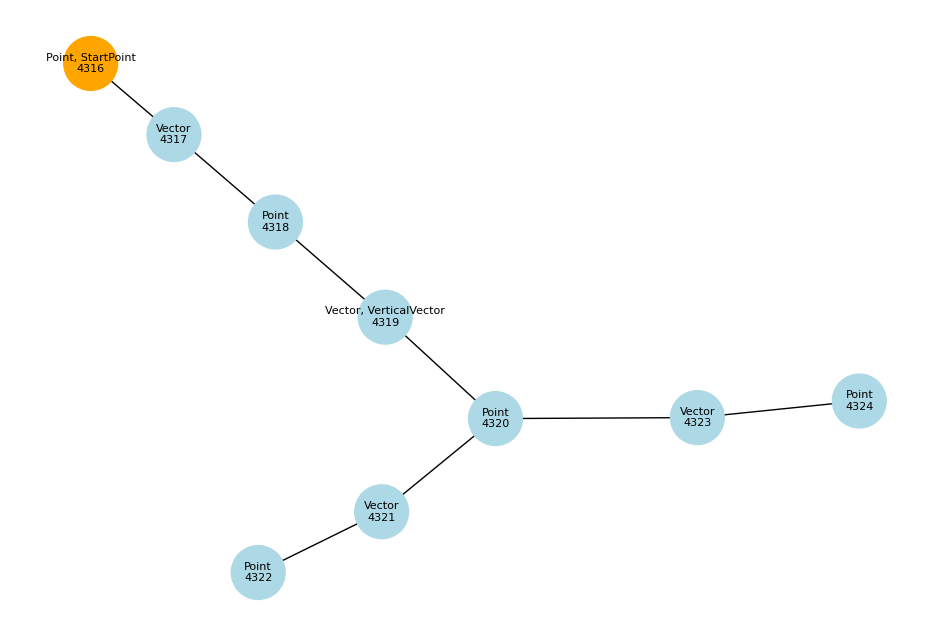

Node	Properties
4:302ef79a-0b04-4334-82b9-01f9754b0950:4316	{'labels': ['Point', 'StartPoint'], 'monotony': 'NON_MONOTONIC', 'relative_distance': 0.5, 'normalized_y': -0.7, 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:4317	{'labels': ['Vector'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'contour_type': 'OPEN', 'quadrant': 1}
4:302ef79a-0b04-4334-82b9-01f9754b0950:4318	{'labels': ['Point'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:4319	{'labels': ['Vector', 'VerticalVector'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'half_plane': 'upper', 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:4320	{'labels': ['Point'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:4321	{'labels': ['Vector'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:43

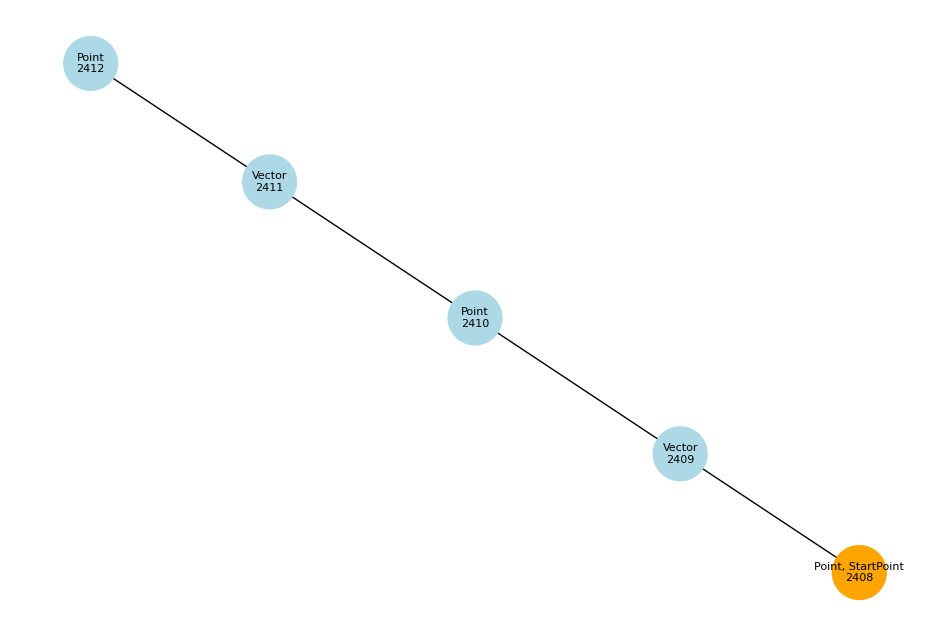

Node	Properties
4:302ef79a-0b04-4334-82b9-01f9754b0950:2408	{'labels': ['Point', 'StartPoint'], 'monotony': 'NON_MONOTONIC', 'relative_distance': 0.2, 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:2409	{'labels': ['Vector'], 'monotony': 'NON_MONOTONIC', 'relative_distance': 0.2, 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:2410	{'labels': ['Point'], 'monotony': 'NON_MONOTONIC', 'relative_distance': 0.2, 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:2411	{'labels': ['Vector'], 'monotony': 'NON_MONOTONIC', 'cycle_count': 0, 'contour_type': 'OPEN'}
4:302ef79a-0b04-4334-82b9-01f9754b0950:2412	{'labels': ['Point'], 'monotony': 'NON_MONOTONIC', 'relative_distance': 0.2, 'cycle_count': 0, 'contour_type': 'OPEN'}


In [89]:
print("Visualizing concept graphs")
for concept_id, combined_score in activated_concepts_with_scores:
    print(f"Visualizing concept graph for {concept_id} with score {combined_score}")
    visualize_networkx_graph(concept_graphs[concept_id])
    print_table_of_properties(concept_graphs[concept_id])